BAGIAN 1: IMPORT LIBRARY

In [15]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, SpatialDropout1D, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

sns.set(style='whitegrid')
tqdm.pandas()

BAGIAN 2: LOAD DATA & LEXICON OVERRIDE

In [16]:
print("[INFO] Memuat Data...")
df = pd.read_csv('dataset_fintech_agregasi.csv')

# Kamus Leksikon
kata_positif = ['bagus', 'mantap', 'keren', 'cepat', 'mudah', 'membantu', 'terbaik', 'puas',
                'lancar', 'aman', 'praktis', 'nyaman', 'suka', 'top', 'good', 'oke', 'ok', 'cuan', 'berguna']
kata_negatif = ['buruk', 'jelek', 'lambat', 'lemot', 'lelet', 'gagal', 'susah', 'kecewa',
                'penipu', 'maling', 'rusak', 'error', 'bug', 'rugi', 'hilang', 'mahal', 'potongan',
                'sampah', 'tolol', 'bego', 'parah', 'anjing', 'babi', 'jancok', 'kendala', 'masalah', 'tutup']

def lexicon_labeling(text):
    text = str(text).lower()
    score_pos = sum(1 for word in kata_positif if word in text)
    score_neg = sum(1 for word in kata_negatif if word in text)

    if score_pos > score_neg: return 'Positif'
    elif score_neg > score_pos: return 'Negatif'
    else: return 'Netral'

print("[INFO] Melakukan Override Label dengan Lexicon...")
df['sentimen'] = df['teks'].apply(lexicon_labeling)
print("Distribusi Label Baru:\n", df['sentimen'].value_counts())

[INFO] Memuat Data...
[INFO] Melakukan Override Label dengan Lexicon...
Distribusi Label Baru:
 sentimen
Netral     6889
Positif    5470
Negatif    2641
Name: count, dtype: int64


BAGIAN 3: PREPROCESSING & PRUNING

In [17]:
slang_dict = {
    "yg": "yang", "gk": "tidak", "ga": "tidak", "gak": "tidak", "ngga": "tidak", "engga": "tidak",
    "sdh": "sudah", "udah": "sudah", "blm": "belum", "dr": "dari", "klo": "kalau",
    "kalo": "kalau", "bs": "bisa", "sy": "saya", "aku": "saya", "gue": "saya", "gw": "saya",
    "bgt": "banget", "anj": "buruk", "jelek": "buruk", "parah": "buruk", "kecewa": "buruk",
    "lola": "lambat", "lemot": "lambat", "lelet": "lambat", "cepet": "cepat",
    "top": "bagus", "good": "bagus", "mantap": "bagus", "keren": "bagus", "ok": "bagus",
    "tf": "transfer", "wd": "tarik", "topup": "isi ulang", "saldo": "uang", "cuan": "untung",
    "apk": "aplikasi", "apps": "aplikasi", "error": "rusak", "bug": "rusak", "login": "masuk",
    "cs": "layanan", "admin": "petugas", "respon": "tanggapan", "dgn": "dengan", "thx": "terima kasih",
    "tdk": "tidak", "jgn": "jangan", "knp": "kenapa", "utk": "untuk"
}

factory_stop = StopWordRemoverFactory()
stopwords_indo = [w for w in factory_stop.get_stop_words() if w not in ['tidak', 'bukan', 'jangan', 'belum', 'kurang', 'tapi']]
stemmer = StemmerFactory().create_stemmer()

def preprocess_text(text):
    text = re.sub(r'[^a-z\s]', ' ', str(text).lower())
    text = re.sub(r'\s+', ' ', text).strip()
    words = [slang_dict.get(w, w) for w in text.split()]
    words = [w for w in words if w not in stopwords_indo]
    return stemmer.stem(' '.join(words))

print("\n[INFO] Membersihkan Teks (Preprocessing)...")
df['teks_bersih'] = df['teks'].progress_apply(preprocess_text)

df = df.dropna(subset=['teks_bersih'])
df['jumlah_kata'] = df['teks_bersih'].apply(lambda x: len(str(x).split()))
df = df[(df['jumlah_kata'] >= 1) & (df['jumlah_kata'] <= 60)]
print(f"Data siap latih: {len(df)} baris.")


[INFO] Membersihkan Teks (Preprocessing)...


100%|██████████| 15000/15000 [15:06<00:00, 16.56it/s] 

Data siap latih: 14845 baris.


BAGIAN 4: SPLITTING & ENCODING

In [19]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['sentimen'])
X = df['teks_bersih']
y = df['label_encoded']

# Split Data (80% Train, 20% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

BAGIAN 5: SKEMA 1 - DEEP LEARNING (BI-LSTM)


SKEMA 1: BIDIRECTIONAL LSTM (DEEP LEARNING)


C:\Users\Advan\PycharmProjects\Analisis sentimen\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


[INFO] Melatih Model Bi-LSTM...
Epoch 1/15
372/372 ━━━━━━━━━━━━━━━━━━━━ 113s 278ms/step - accuracy: 0.7996 - loss: 0.4729 - val_accuracy: 0.9336 - val_loss: 0.2034
Epoch 2/15
372/372 ━━━━━━━━━━━━━━━━━━━━ 102s 273ms/step - accuracy: 0.9365 - loss: 0.1832 - val_accuracy: 0.9451 - val_loss: 0.1696
Epoch 3/15
372/372 ━━━━━━━━━━━━━━━━━━━━ 100s 268ms/step - accuracy: 0.9513 - loss: 0.1318 - val_accuracy: 0.9431 - val_loss: 0.1748
Epoch 4/15
372/372 ━━━━━━━━━━━━━━━━━━━━ 96s 258ms/step - accuracy: 0.9625 - loss: 0.1004 - val_accuracy: 0.9481 - val_loss: 0.1745
Epoch 5/15
372/372 ━━━━━━━━━━━━━━━━━━━━ 96s 258ms/step - accuracy: 0.9702 - loss: 0.0808 - val_accuracy: 0.9424 - val_loss: 0.1864
Epoch 6/15
372/372 ━━━━━━━━━━━━━━━━━━━━ 95s 255ms/step - accuracy: 0.9763 - loss: 0.0656 - val_accuracy: 0.9306 - val_loss: 0.2599
Epoch 7/15
372/372 ━━━━━━━━━━━━━━━━━━━━ 93s 251ms/step - accuracy: 0.9790 - loss: 0.0570 - val_accuracy: 0.9424 - val_loss: 0.2059
Epoch 8/15
372/372 ━━━━━━━━━━━━━━━━━━━━ 88s 238m

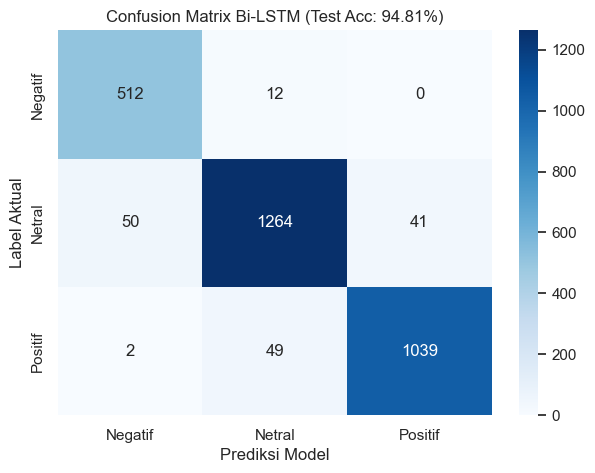

In [20]:
print("\n" + "="*50)
print("SKEMA 1: BIDIRECTIONAL LSTM (DEEP LEARNING)")
print("="*50)

MAX_NB_WORDS = 10000
MAX_SEQUENCE_LENGTH = 100
tokenizer = Tokenizer(num_words=MAX_NB_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['teks_bersih'])

X_lstm = pad_sequences(tokenizer.texts_to_sequences(df['teks_bersih']), maxlen=MAX_SEQUENCE_LENGTH)
y_lstm = pd.get_dummies(df['sentimen']).values

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42, stratify=df['sentimen'])

y_train_1d = np.argmax(y_train_lstm, axis=1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_1d), y=y_train_1d)
weight_dict = dict(enumerate(class_weights))

model_lstm = Sequential([
    Embedding(MAX_NB_WORDS, 100, input_length=MAX_SEQUENCE_LENGTH),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_lstm.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

print("[INFO] Melatih Model Bi-LSTM...")
model_lstm.fit(X_train_lstm, y_train_lstm, epochs=15, batch_size=32, validation_data=(X_test_lstm, y_test_lstm), callbacks=[early_stop], class_weight=weight_dict, verbose=1)

# EVALUASI BI-LSTM (TRAIN & TEST)
train_acc_lstm = model_lstm.evaluate(X_train_lstm, y_train_lstm, verbose=0)[1]
test_acc_lstm = model_lstm.evaluate(X_test_lstm, y_test_lstm, verbose=0)[1]
print(f"\n[HASIL SKEMA 1 - BI-LSTM]")
print(f"--> Akurasi Training : {train_acc_lstm*100:.2f}%")
print(f"--> Akurasi Testing  : {test_acc_lstm*100:.2f}%")

# BUKTI VISUAL: CONFUSION MATRIX BI-LSTM
y_pred_lstm_prob = model_lstm.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)
y_test_lstm_1d = np.argmax(y_test_lstm, axis=1)

cm = confusion_matrix(y_test_lstm_1d, y_pred_lstm)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix Bi-LSTM (Test Acc: {test_acc_lstm*100:.2f}%)')
plt.ylabel('Label Aktual')
plt.xlabel('Prediksi Model')
plt.show()

BAGIAN 6: SKEMA 2 & 3 - MACHINE LEARNING TRADISIONAL

In [21]:
print("\n" + "="*50)
print("SKEMA 2 & 3: SVM DAN RANDOM FOREST")
print("="*50)

tfidf = TfidfVectorizer(max_features=7000, ngram_range=(1, 1))
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

# --- SKEMA 2: SVM ---
svm_model = SVC(kernel='linear', C=1.5, probability=True, class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)

train_acc_svm = accuracy_score(y_train, svm_model.predict(X_train_tfidf))
test_acc_svm = accuracy_score(y_test, svm_model.predict(X_test_tfidf))
print(f"\n[HASIL SKEMA 2 - SVM]")
print(f"--> Akurasi Training : {train_acc_svm*100:.2f}%")
print(f"--> Akurasi Testing  : {test_acc_svm*100:.2f}%")

# --- SKEMA 3: RANDOM FOREST ---
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train_tfidf, y_train)

train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train_tfidf))
test_acc_rf = accuracy_score(y_test, rf_model.predict(X_test_tfidf))
print(f"\n[HASIL SKEMA 3 - RANDOM FOREST]")
print(f"--> Akurasi Training : {train_acc_rf*100:.2f}%")
print(f"--> Akurasi Testing  : {test_acc_rf*100:.2f}%")


SKEMA 2 & 3: SVM DAN RANDOM FOREST

[HASIL SKEMA 2 - SVM]
--> Akurasi Training : 96.36%
--> Akurasi Testing  : 92.32%

[HASIL SKEMA 3 - RANDOM FOREST]
--> Akurasi Training : 99.65%
--> Akurasi Testing  : 87.87%


BAGIAN 7: INFERENSI MODEL

In [22]:
print("\n" + "="*50)
print("PENGUJIAN INFERENSI MODEL TERBAIK (BI-LSTM)")
print("="*50)

def uji_kalimat_baru(teks):
    teks_bersih = preprocess_text(teks)
    sequence = tokenizer.texts_to_sequences([teks_bersih])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH)

    prediksi_prob = model_lstm.predict(padded_sequence, verbose=0)
    indeks_kelas = np.argmax(prediksi_prob, axis=1)[0]

    label_kategori = le.inverse_transform([indeks_kelas])[0]
    keyakinan = np.max(prediksi_prob) * 100

    print(f"Input    : '{teks}'")
    print(f"Prediksi : {label_kategori.upper()} (Keyakinan: {keyakinan:.2f}%)\n" + "-"*50)

# Uji Coba Kategorikal
uji_kalimat_baru("Aplikasinya bagus banget, transfer uang jadi gampang dan cepat masuknya. Mantap!")
uji_kalimat_baru("Sangat kecewa, saldo kepotong tapi transaksi gagal. CS ditanya malah muter-muter.")
uji_kalimat_baru("Baru update versi terbaru, sejauh ini belum ada kendala yang berarti sih.")


PENGUJIAN INFERENSI MODEL TERBAIK (BI-LSTM)
Input    : 'Aplikasinya bagus banget, transfer uang jadi gampang dan cepat masuknya. Mantap!'
Prediksi : POSITIF (Keyakinan: 99.99%)
--------------------------------------------------
Input    : 'Sangat kecewa, saldo kepotong tapi transaksi gagal. CS ditanya malah muter-muter.'
Prediksi : NEGATIF (Keyakinan: 99.99%)
--------------------------------------------------
Input    : 'Baru update versi terbaru, sejauh ini belum ada kendala yang berarti sih.'
Prediksi : NEGATIF (Keyakinan: 95.02%)
--------------------------------------------------
